# Per-cell distributions

Per-dataset, cell-level QC distributions read from each dataset's `inference_mudata.h5mu`. Pick a dataset by editing the `SHORT_NAME` cell below, then re-run all.

Outputs land in `results/per_dataset_distributions/<SLUG>/`:

- UMI per cell (gene, guide, and HTO if present)
- Guides assigned per cell vs target MOI
- Cells in each assignment category (no assignment, single guide, NTC-only, targeting-only, mixed)
- Cells per guide and per intended target


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp

import matplotlib.pyplot as plt
import matplotlib as mpl

import h5py
try:
    from anndata.io import read_elem
except ImportError:  # anndata < 0.11
    from anndata.experimental import read_elem

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [ ]:
# Dataset selector. Set to one of the short_name values in manifest.tsv:
#   "Hon CM", "Huangfu DE", "Huangfu ESC", "Gersbach Hep"
SHORT_NAME = "Hon CM"
SLUG = SHORT_NAME.replace(" ", "_")
print(f"Selected dataset: {SHORT_NAME}", file=sys.stderr)

In [6]:
# Paths, colors, manifest lookup
PROJECT_ROOT = Path("/cellar/users/aklie/projects/tf_perturb_seq")
sys.path.append(str(PROJECT_ROOT / "config"))
from loader import load_colors

dataset_colors = load_colors("production_TF-Perturb-seq", "dataset_colors")

BASE_DIR = PROJECT_ROOT / "docs" / "jamborees" / "2026_UTSW" / "working_groups" / "wg1_data_qc" / "pipeline_qc"
QC_PATHS_FILE = BASE_DIR / "manifests" / "manifest.tsv"

paths_df = pd.read_csv(QC_PATHS_FILE, sep="\t")
row = paths_df[paths_df['short_name'] == SHORT_NAME].iloc[0]
DATASET = row['dataset']
MUDATA_PATH = row['mudata']
COLOR = dataset_colors[DATASET]

OUTPUT_DIR = BASE_DIR / "results" / "per_dataset_distributions" / SLUG
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset:   {DATASET}")
print(f"Short:     {SHORT_NAME}")
print(f"h5mu:      {MUDATA_PATH}")
print(f"Output:    {OUTPUT_DIR}")
print(f"Color:     {COLOR}")

Dataset:   Hon_WTC11-cardiomyocyte-differentiation_TF-Perturb-seq
Short:     Hon CM
h5mu:      /cellar/users/aklie/projects/tf_perturb_seq/datasets/Hon_WTC11-cardiomyocyte-differentiation_TF-Perturb-seq/synapse_inference_mudata/inference_mudata.h5mu
Output:    /cellar/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/pipeline_qc/results/per_dataset_distributions/Hon_CM
Color:     #D7263D


## Load the h5mu

In [7]:
# Lightweight load: read ONLY the obs DataFrames, the guide_assignment sparse layer,
# the guide var DataFrame, the uns/moi descriptor, and (if present) the hashing X.
# Skips the gene/guide X matrices and all of uns/{cis,trans}_per_*_results, which
# would otherwise dominate the memory footprint (trans_per_guide_results alone is
# ~10 GB for some of these datasets).
with h5py.File(MUDATA_PATH, "r") as h5:
    modalities = list(h5["mod"].keys())
    HAS_HTO = "hashing" in modalities

    gene_obs         = read_elem(h5["mod/gene/obs"])
    guide_obs        = read_elem(h5["mod/guide/obs"])
    guide_var        = read_elem(h5["mod/guide/var"])
    guide_assignment = read_elem(h5["mod/guide/layers/guide_assignment"])

    # tiny scalar — pull as a raw h5 read
    _moi = h5["mod/guide/uns/moi"][0]
    target_moi = _moi.decode() if isinstance(_moi, bytes) else _moi

    # HTO X is small (n_cells x ~10 barcodes); load only when the modality is present
    if HAS_HTO:
        hto_X = read_elem(h5["mod/hashing/X"])
        hto_umi_per_cell = np.asarray(hto_X.sum(axis=1)).ravel()
    else:
        hto_umi_per_cell = None

print(f"Modalities:  {modalities}")
print(f"Has HTO:     {HAS_HTO}")
print(f"n_cells:     {len(gene_obs):,}")
print(f"n_guides:    {len(guide_var):,}")
print(f"Target MOI:  {target_moi!r}")

Modalities:  ['gene', 'guide', 'hashing']
Has HTO:     True
n_cells:     1,004,091
n_guides:    14,151
Target MOI:  'high'


## Build per-cell summary table

One row per cell with the metrics we'll plot below.

In [8]:
# # guides assigned per cell, derived from the binary guide_assignment layer
ga = guide_assignment
if not sp.issparse(ga):
    ga = sp.csr_matrix(ga)
n_assigned = np.asarray(ga.sum(axis=1)).ravel()

cell = pd.DataFrame({
    'gene_umi':           gene_obs['n_counts'].astype(float).values,
    'pct_mito':           gene_obs['percent_mito'].astype(float).values,
    'log1p_n_genes':      gene_obs['log1p_n_genes_by_counts'].astype(float).values,
    'guide_umi':          guide_obs['total_guide_umis'].astype(float).values,
    'n_expressed_guides': guide_obs['num_expressed_guides'].astype(int).values,
    'n_assigned_guides':  n_assigned.astype(int),
}, index=gene_obs.index)

if HAS_HTO:
    cell['hto_umi'] = hto_umi_per_cell

n_cells = len(cell)
print(f"n_cells = {n_cells:,}")
cell.describe()

n_cells = 1,004,091


,gene_umi,pct_mito,log1p_n_genes,guide_umi,n_expressed_guides,n_assigned_guides,hto_umi
count,1.004091e+06,1.004091e+06,1.004091e+06,1.004091e+06,1.004091e+06,1.004091e+06,1.004091e+06
mean,1.386783e+03,4.139558e+00,6.976946e+00,5.283821e+02,2.054856e+01,2.691406e+00,3.209809e+02
std,7.415252e+02,2.869516e+00,8.864080e-01,6.464917e+02,9.984003e+00,1.698466e+00,1.818064e+03
min,4.600000e+01,0.000000e+00,3.850148e+00,1.000000e+00,1.000000e+00,0.000000e+00,2.200000e+01
25%,9.400000e+02,2.081201e+00,6.846943e+00,6.500000e+01,1.400000e+01,2.000000e+00,1.700000e+02
50%,1.427000e+03,3.592814e+00,7.264030e+00,3.030000e+02,1.900000e+01,2.000000e+00,2.480000e+02
75%,1.855000e+03,5.565142e+00,7.526179e+00,7.390000e+02,2.500000e+01,4.000000e+00,3.720000e+02
max,7.042000e+03,1.499876e+01,8.859789e+00,1.286300e+04,2.990000e+02,7.500000e+01,8.751070e+05


## UMI per cell (gene, guide, HTO if present)

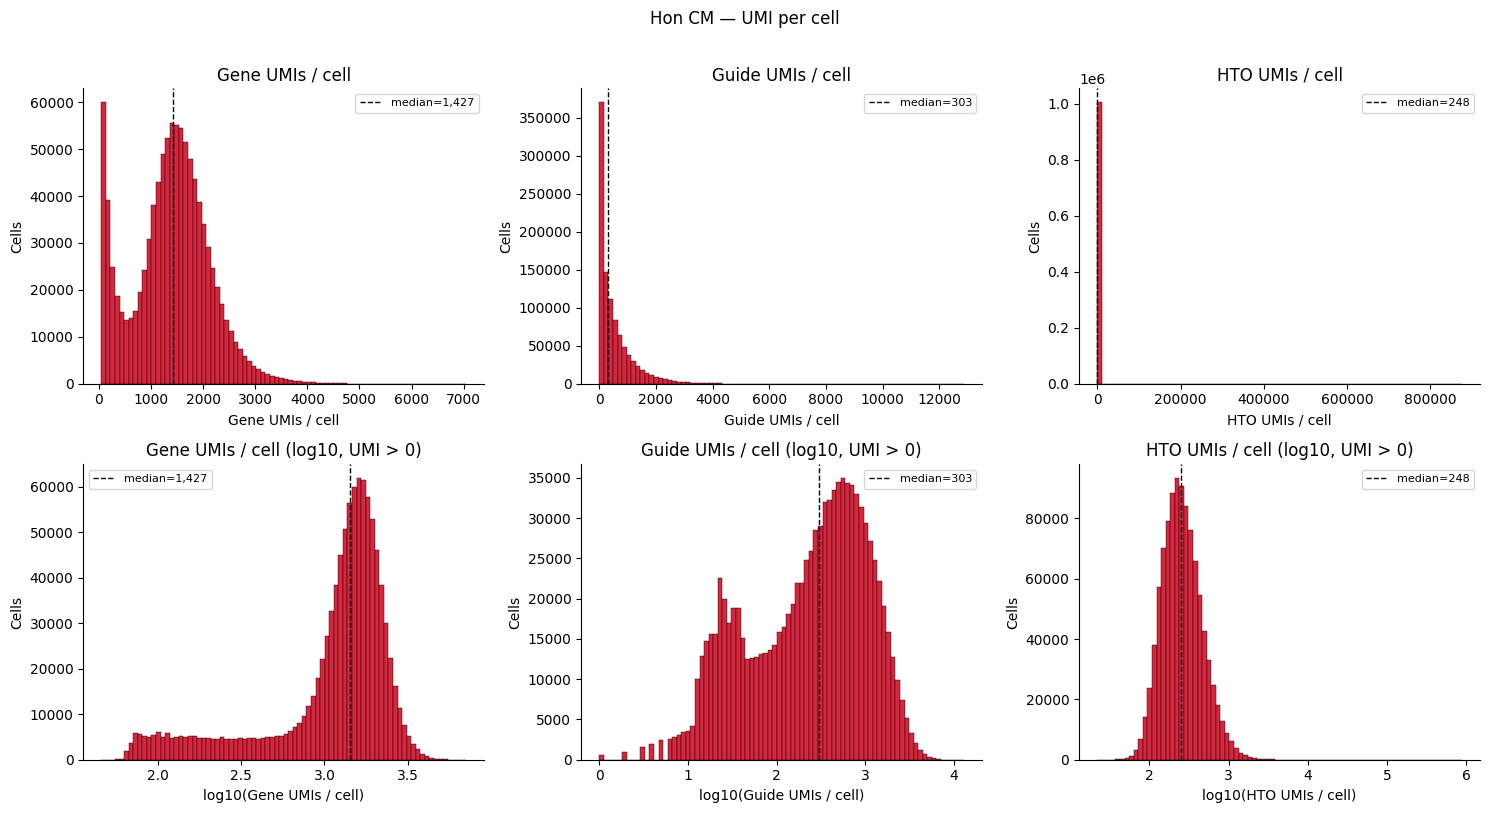

In [9]:
panels = [('gene_umi', 'Gene UMIs / cell'),
          ('guide_umi', 'Guide UMIs / cell')]
if HAS_HTO:
    panels.append(('hto_umi', 'HTO UMIs / cell'))

fig, axes = plt.subplots(2, len(panels), figsize=(5 * len(panels), 8))
if len(panels) == 1:
    axes = axes.reshape(2, 1)

for j, (col, title) in enumerate(panels):
    vals = cell[col].values
    vals = vals[~np.isnan(vals)]
    pos = vals[vals > 0]

    # Linear top, log10 bottom
    ax = axes[0, j]
    ax.hist(vals, bins=80, color=COLOR, edgecolor='black', linewidth=0.3)
    ax.axvline(np.median(vals), color='black', linestyle='--', linewidth=1,
               label=f'median={np.median(vals):,.0f}')
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Cells')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axes[1, j]
    if len(pos) > 0:
        ax.hist(np.log10(pos), bins=80, color=COLOR, edgecolor='black', linewidth=0.3)
        ax.axvline(np.log10(np.median(pos)), color='black', linestyle='--', linewidth=1,
                   label=f'median={np.median(pos):,.0f}')
    ax.set_title(f"{title} (log10, UMI > 0)")
    ax.set_xlabel(f"log10({title})")
    ax.set_ylabel('Cells')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(f"{SHORT_NAME} — UMI per cell", y=1.01, fontsize=12)
plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"umi_per_cell.{ext}", dpi=300, bbox_inches='tight')
plt.show()

## Gene quality (genes/cell, % mito)

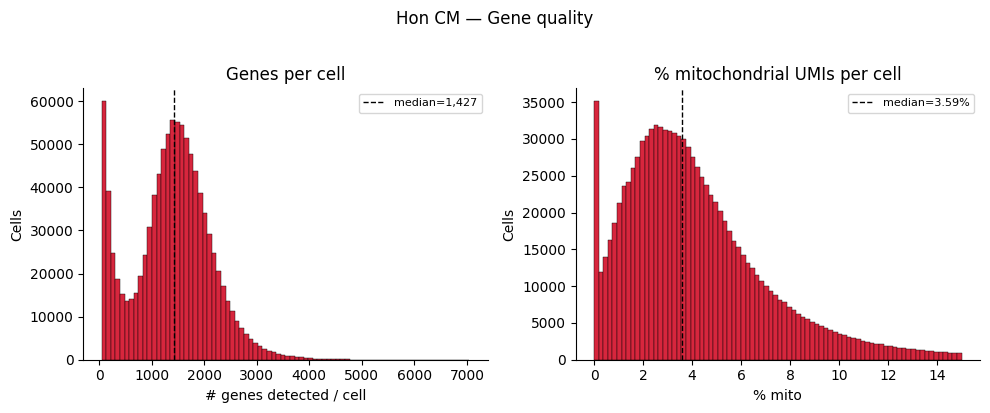

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
n_genes = np.expm1(cell['log1p_n_genes'].values)  # invert log1p
ax.hist(n_genes, bins=80, color=COLOR, edgecolor='black', linewidth=0.3)
ax.axvline(np.median(n_genes), color='black', linestyle='--', linewidth=1,
           label=f'median={np.median(n_genes):,.0f}')
ax.set_xlabel('# genes detected / cell')
ax.set_ylabel('Cells')
ax.set_title('Genes per cell')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
ax.hist(cell['pct_mito'].values, bins=80, color=COLOR, edgecolor='black', linewidth=0.3)
ax.axvline(np.median(cell['pct_mito']), color='black', linestyle='--', linewidth=1,
           label=f'median={np.median(cell["pct_mito"]):.2f}%')
ax.set_xlabel('% mito')
ax.set_ylabel('Cells')
ax.set_title('% mitochondrial UMIs per cell')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle(f"{SHORT_NAME} — Gene quality", y=1.02, fontsize=12)
plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"gene_quality.{ext}", dpi=300, bbox_inches='tight')
plt.show()

## Guides assigned per cell

Target MOI is the design intent (typically ~2 guides/cell for these libraries).
The histogram below shows the realized distribution.

In [11]:
# target_moi was loaded in the lightweight read cell above
print(f"Reported MOI (uns['moi']): {target_moi!r}")

# Bin assigned guides per cell into 0, 1, 2, 3, 4, 5+
n = cell['n_assigned_guides'].values
bins_assigned = pd.cut(
    n,
    bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, np.inf],
    labels=['0', '1', '2', '3', '4', '5+'],
)
assigned_counts = bins_assigned.value_counts().sort_index()
assigned_pct = (assigned_counts / n_cells * 100).round(2)

bins_expressed = pd.cut(
    cell['n_expressed_guides'].values,
    bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, np.inf],
    labels=['0', '1', '2', '3', '4', '5+'],
)
expressed_counts = bins_expressed.value_counts().sort_index()
expressed_pct = (expressed_counts / n_cells * 100).round(2)

guides_table = pd.DataFrame({
    'n_cells_assigned': assigned_counts.astype(int),
    'pct_assigned': assigned_pct,
    'n_cells_expressed_umi_gt_0': expressed_counts.astype(int),
    'pct_expressed_umi_gt_0': expressed_pct,
})
guides_table.to_csv(OUTPUT_DIR / "guides_per_cell_breakdown.tsv", sep="\t")
guides_table

Reported MOI (uns['moi']): 'high'


,n_cells_assigned,pct_assigned,n_cells_expressed_umi_gt_0,pct_expressed_umi_gt_0
0,28978,2.89,0,0.00
1,212264,21.14,1076,0.11
2,282128,28.10,3033,0.30
3,224389,22.35,6121,0.61
4,135392,13.48,9808,0.98
5+,120940,12.04,984053,98.00


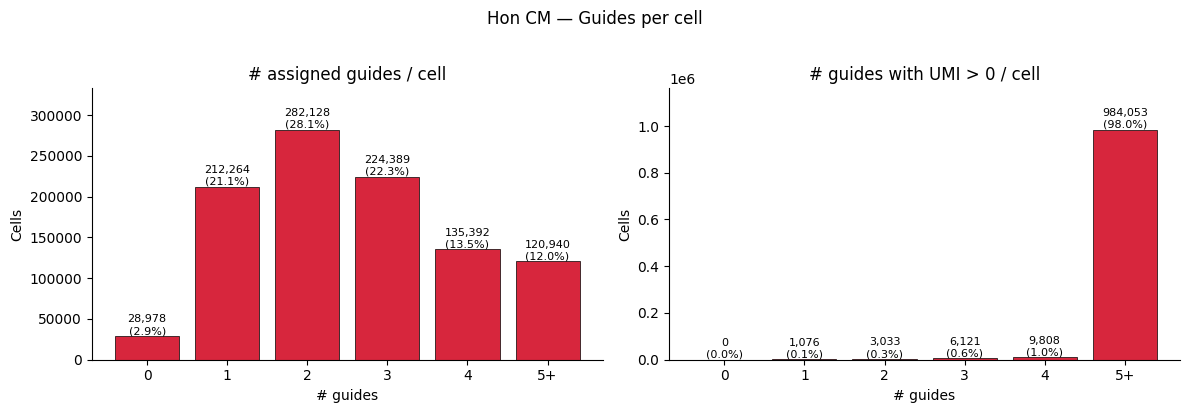

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (counts, title) in zip(
    axes,
    [(assigned_counts, '# assigned guides / cell'),
     (expressed_counts, '# guides with UMI > 0 / cell')],
):
    bars = ax.bar(counts.index.astype(str), counts.values, color=COLOR,
                  edgecolor='black', linewidth=0.5)
    for bar, n_val in zip(bars, counts.values):
        pct = n_val / n_cells * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{n_val:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=8)
    ax.set_xlabel('# guides')
    ax.set_ylabel('Cells')
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, counts.max() * 1.18)

plt.suptitle(f"{SHORT_NAME} — Guides per cell", y=1.02, fontsize=12)
plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"guides_per_cell.{ext}", dpi=300, bbox_inches='tight')
plt.show()

## Single-guide cells vs NTC-only cells

- **Single guide:** exactly one guide assigned (the cleanest cells for downstream inference).
- **NTC-only:** at least one guide assigned, all of which are non-targeting controls.

In [13]:
# Identify non-targeting guides — guide_var was loaded in the lightweight read cell above
if 'type' in guide_var.columns:
    is_ntc = guide_var['type'].astype(str).str.contains('non.targeting|non_targeting', regex=True, case=False).values
elif 'label' in guide_var.columns:
    is_ntc = guide_var['label'].astype(str).str.contains('non.targeting|non_targeting', regex=True, case=False).values
else:
    raise RuntimeError("Could not find guide type/label column to identify NTCs.")

ntc_idx = np.where(is_ntc)[0]
non_ntc_idx = np.where(~is_ntc)[0]
print(f"NTC guides:     {is_ntc.sum()}")
print(f"non-NTC guides: {(~is_ntc).sum()}")

# Per-cell assigned counts split by NTC vs non-NTC
ga_csc = ga.tocsc() if not isinstance(ga, sp.csc_matrix) else ga
ntc_counts = np.asarray(ga_csc[:, ntc_idx].sum(axis=1)).ravel()
nontc_counts = np.asarray(ga_csc[:, non_ntc_idx].sum(axis=1)).ravel()
total = ntc_counts + nontc_counts

cats = pd.Series(np.where(
    total == 0, 'no assignment',
    np.where(total == 1, 'exactly 1',
    np.where(nontc_counts == 0, 'NTC-only (≥2)',
    np.where(ntc_counts == 0, 'targeting-only (≥2)', 'mixed')))
))
breakdown = cats.value_counts().reindex(
    ['no assignment', 'exactly 1', 'NTC-only (≥2)', 'targeting-only (≥2)', 'mixed']
).fillna(0).astype(int)
breakdown_pct = (breakdown / n_cells * 100).round(2)
single_guide_pct = (total == 1).sum() / n_cells * 100
ge1_pct = (total >= 1).sum() / n_cells * 100

print(f"\nCells with exactly 1 guide:  {(total == 1).sum():,} ({single_guide_pct:.2f}%)")
print(f"Cells with ≥1 guide:          {(total >= 1).sum():,} ({ge1_pct:.2f}%)")
print(f"Cells with only NTC guides:  {((ntc_counts >= 1) & (nontc_counts == 0)).sum():,}")
print(f"  of which exactly 1 NTC:     {((ntc_counts == 1) & (nontc_counts == 0)).sum():,}")

summary_table = pd.DataFrame({'n_cells': breakdown, 'pct_cells': breakdown_pct})
summary_table.to_csv(OUTPUT_DIR / "guide_category_breakdown.tsv", sep="\t")
summary_table

NTC guides:     600
non-NTC guides: 13551

Cells with exactly 1 guide:  212,264 (21.14%)
Cells with ≥1 guide:          975,113 (97.11%)
Cells with only NTC guides:  12,252
  of which exactly 1 NTC:     6,853


,n_cells,pct_cells
no assignment,28978,2.89
exactly 1,212264,21.14
NTC-only (≥2),5399,0.54
targeting-only (≥2),692245,68.94
mixed,65205,6.49


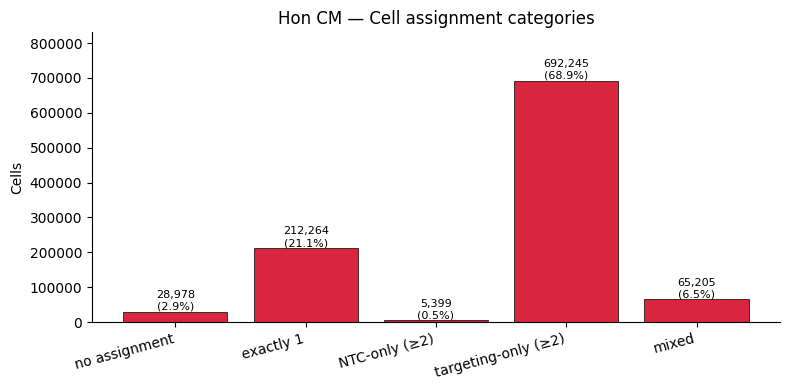

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(breakdown.index, breakdown.values, color=COLOR, edgecolor='black', linewidth=0.5)
for bar, n_val in zip(bars, breakdown.values):
    pct = n_val / n_cells * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{n_val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Cells')
ax.set_title(f'{SHORT_NAME} — Cell assignment categories')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, breakdown.max() * 1.2)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"guide_category_breakdown.{ext}", dpi=300, bbox_inches='tight')
plt.show()

## Cells per guide and per target

In [15]:
# Cells assigned per guide = column sums
cells_per_guide = np.asarray(ga_csc.sum(axis=0)).ravel()
guide_df = pd.DataFrame({
    'guide_id': guide_var['guide_id'].astype(str).values if 'guide_id' in guide_var else guide_var.index.astype(str),
    'is_ntc': is_ntc,
    'n_cells': cells_per_guide,
})
guide_df.to_csv(OUTPUT_DIR / "cells_per_guide.tsv", sep="\t", index=False)
print(f"Guides: {len(guide_df):,}")
print(guide_df['n_cells'].describe())

Guides: 14,151
count    14151.000000
mean       190.970037
std        228.644492
min          0.000000
25%         71.000000
50%        147.000000
75%        238.500000
max       9532.000000
Name: n_cells, dtype: float64


In [16]:
# Cells per target — group guides by intended_target_name (or gene_name fallback)
if 'intended_target_name' in guide_var.columns:
    target_col = 'intended_target_name'
elif 'gene_name' in guide_var.columns:
    target_col = 'gene_name'
else:
    target_col = None

if target_col is not None:
    targets = guide_var[target_col].astype(str).fillna('NA').values
    target_df = (
        pd.DataFrame({'target': targets, 'n_cells': cells_per_guide, 'is_ntc': is_ntc})
        .groupby('target', as_index=False)
        .agg(n_cells=('n_cells', 'sum'), n_guides=('n_cells', 'size'), is_ntc=('is_ntc', 'all'))
        .sort_values('n_cells', ascending=False)
    )
    target_df.to_csv(OUTPUT_DIR / "cells_per_target.tsv", sep="\t", index=False)
    print(f"Targets: {len(target_df):,}")
    print(target_df['n_cells'].describe())
else:
    target_df = None
    print("No target column found.")

Targets: 2,161
count     2161.000000
mean      1250.540028
std        826.467437
min          3.000000
25%        787.000000
50%       1083.000000
75%       1548.000000
max      10508.000000
Name: n_cells, dtype: float64


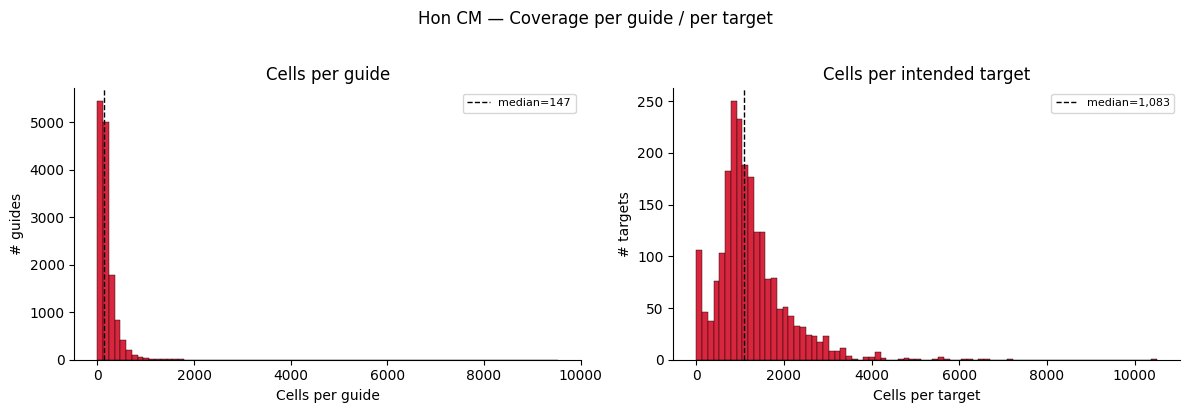

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
vals = guide_df['n_cells'].values
ax.hist(vals[vals > 0], bins=80, color=COLOR, edgecolor='black', linewidth=0.3)
ax.axvline(np.median(vals), color='black', linestyle='--', linewidth=1,
           label=f'median={np.median(vals):,.0f}')
ax.set_xlabel('Cells per guide')
ax.set_ylabel('# guides')
ax.set_title('Cells per guide')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
if target_df is not None:
    tvals = target_df['n_cells'].values
    ax.hist(tvals[tvals > 0], bins=80, color=COLOR, edgecolor='black', linewidth=0.3)
    ax.axvline(np.median(tvals), color='black', linestyle='--', linewidth=1,
               label=f'median={np.median(tvals):,.0f}')
    ax.set_xlabel('Cells per target')
    ax.set_ylabel('# targets')
    ax.set_title('Cells per intended target')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'no target column', ha='center', va='center', transform=ax.transAxes)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle(f"{SHORT_NAME} — Coverage per guide / per target", y=1.02, fontsize=12)
plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"cells_per_guide_and_target.{ext}", dpi=300, bbox_inches='tight')
plt.show()

## Save the per-cell summary

In [18]:
cell.to_csv(OUTPUT_DIR / "per_cell_summary.tsv.gz", sep="\t", compression='gzip')
print(f"Saved per-cell summary ({n_cells:,} rows) to {OUTPUT_DIR / 'per_cell_summary.tsv.gz'}")

Saved per-cell summary (1,004,091 rows) to /cellar/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/pipeline_qc/results/per_dataset_distributions/Hon_CM/per_cell_summary.tsv.gz


---
# DONE!